In [ ]:
import numpy as np
import tensorflow as tf
from keras import layers, models
from keras.datasets import mnist
import matplotlib.pyplot as plt

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to range [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape images to (28, 28, 1)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# Perform PCA for different number of latent variables
latent_dims = [2, 4, 8, 16, 32, 64]

# Select 5 random images from test set
random_image_indices = np.random.choice(X_test.shape[0], 5, replace=False)
random_images = X_test[random_image_indices]

11490434/11490434 [==============================] - 0s 0us/step


In [ ]:
def build_vae(latent_dim):
    # Encoder
    encoder_inputs = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_inputs)
    x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
    x = layers.Flatten()(x)
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

    # Reparameterization
    def sampling(args):
        z_mean, z_log_var = args
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    z = layers.Lambda(sampling)([z_mean, z_log_var])

    # Decoder
    decoder_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * 64, activation='relu')(decoder_inputs)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
    x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
    decoder_outputs = layers.Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(x)

    # Define models
    encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
    decoder = models.Model(decoder_inputs, decoder_outputs, name='decoder')
    vae_outputs = decoder(encoder(encoder_inputs)[2])
    vae = models.Model(encoder_inputs, vae_outputs, name='vae')

    return vae, encoder, decoder

Epoch 1/10
469/469 [==============================] - 97s 199ms/step - loss: 0.2565
Epoch 2/10
469/469 [==============================] - 86s 184ms/step - loss: 0.2087
Epoch 3/10
469/469 [==============================] - 84s 179ms/step - loss: 0.1983
Epoch 4/10
469/469 [==============================] - 84s 178ms/step - loss: 0.1944
Epoch 5/10
469/469 [==============================] - 84s 179ms/step - loss: 0.1923
Epoch 6/10
469/469 [==============================] - 87s 186ms/step - loss: 0.1909
Epoch 7/10
469/469 [==============================] - 85s 180ms/step - loss: 0.1898
Epoch 8/10
469/469 [==============================] - 83s 178ms/step - loss: 0.1890
Epoch 9/10
469/469 [==============================] - 85s 181ms/step - loss: 0.1882
Epoch 10/10
1/1 [==============================] - 0s 178ms/step


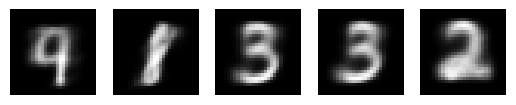

Epoch 1/10
469/469 [==============================] - 85s 177ms/step - loss: 0.2367
Epoch 2/10
469/469 [==============================] - 84s 180ms/step - loss: 0.1667
Epoch 3/10
469/469 [==============================] - 83s 178ms/step - loss: 0.1603
Epoch 4/10
469/469 [==============================] - 85s 180ms/step - loss: 0.1573
Epoch 5/10
469/469 [==============================] - 84s 179ms/step - loss: 0.1553
Epoch 6/10
469/469 [==============================] - 84s 179ms/step - loss: 0.1539
Epoch 7/10
469/469 [==============================] - 86s 184ms/step - loss: 0.1528
Epoch 8/10
469/469 [==============================] - 83s 177ms/step - loss: 0.1520
Epoch 9/10
469/469 [==============================] - 84s 179ms/step - loss: 0.1511
Epoch 10/10
1/1 [==============================] - 0s 110ms/step


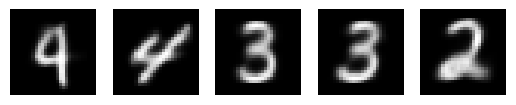

Epoch 1/10
361/469 [======================>.......] - ETA: 19s - loss: 0.2293

KeyboardInterrupt: 

In [ ]:
for latent_dim in latent_dims:
    vae, encoder, decoder = build_vae(latent_dim)
    vae.compile(optimizer='adam', loss='binary_crossentropy')

    vae.fit(X_train, X_train, epochs=10, batch_size=128)

    # Generate images using random samples from the test set
    _, _, random_encoded_images = encoder.predict(random_images)
    generated_images = decoder.predict(random_encoded_images)

    for i, image in enumerate(generated_images):
        plt.subplot(1, 5, i+1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.axis('off')
    plt.show()